In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Charger les données ACP
X_pca = pd.read_csv("D:/imen-chabchoub/FAC/BDIA2-2/data-mining/datamining1/data/processed/X_pca_clusters.csv")

X_pca_2 = X_pca[["PC1", "PC2"]].values
y = X_pca["price_range"].values

In [3]:

# K‑means sur les 2 premiers axes de l’ACP
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_pca_2)

# Créer un DataFrame avec PC1, PC2, clusters et price_range
data_acp = X_pca[["PC1", "PC2"]].copy()   # uniquement les colonnes PC1, PC2
data_acp["cluster"] = clusters
data_acp["price_range"] = y

print("Répartition des clusters :")
print(data_acp["cluster"].value_counts())

Répartition des clusters :
cluster
3    640
0    523
1    500
2    337
Name: count, dtype: int64


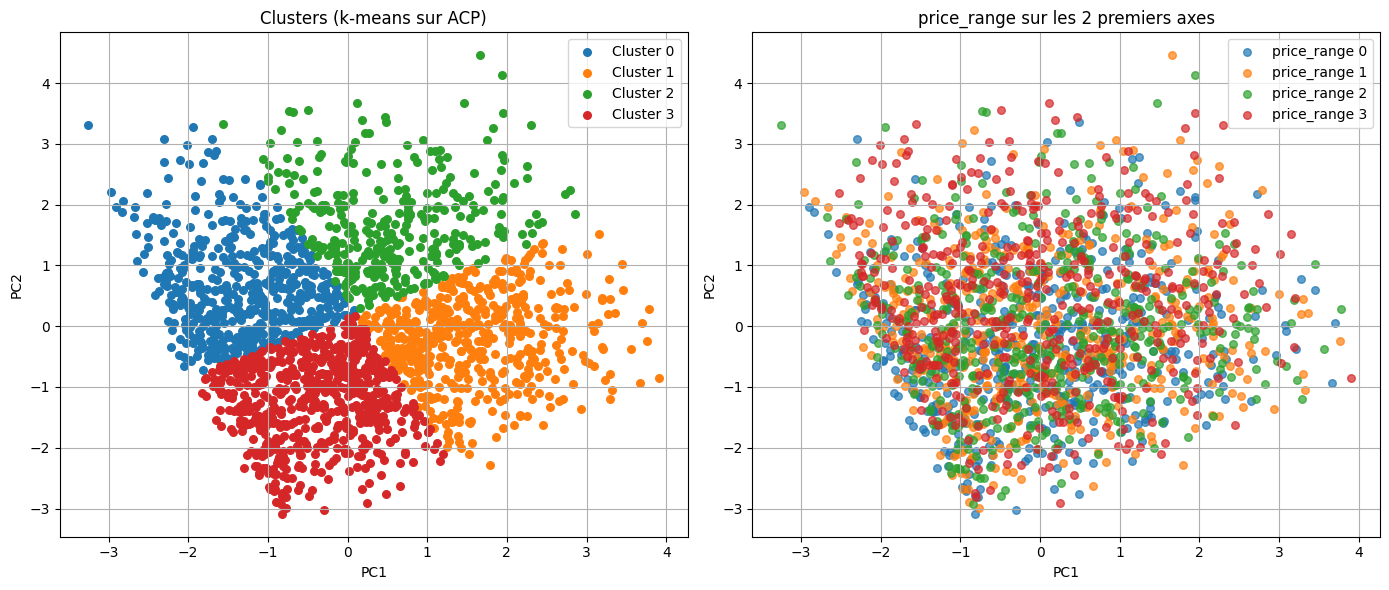

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Cluster vs axe 1-2
plt.subplot(1, 2, 1)
for i in range(k):
    mask = (clusters == i)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=f"Cluster {i}", s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters (k‑means sur ACP)")
plt.legend()
plt.grid(True)

# Clusters colorés par price_range
plt.subplot(1, 2, 2)
for c in np.sort(np.unique(y)):   # ici np.unique au lieu de y.unique()
    mask = (y == c)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=f"price_range {c}", s=30, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("price_range sur les 2 premiers axes")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

supervisée Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
# Chemin vers les données préparées
data_path = "C:/Users/dell/Desktop/DM/datamining1/data/processed/"

X_train = pd.read_csv(f"{data_path}X_train_scaled.csv")
X_test  = pd.read_csv(f"{data_path}X_test_scaled.csv")
y_train = pd.read_csv(f"{data_path}y_train.csv").squeeze()
y_test  = pd.read_csv(f"{data_path}y_test.csv").squeeze()

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1600, 20)
X_test  : (400, 20)
y_train : (1600,)
y_test  : (400,)


In [3]:
print("Distribution y_train :")
print(y_train.value_counts())

print("\nDistribution y_test :")
print(y_test.value_counts())

Distribution y_train :
price_range
1    400
0    400
3    400
2    400
Name: count, dtype: int64

Distribution y_test :
price_range
3    100
1    100
0    100
2    100
Name: count, dtype: int64


In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest entraîné")

Random Forest entraîné


In [5]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy Random Forest :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest : 0.88

Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.83      0.83      0.83       100
           2       0.81      0.80      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



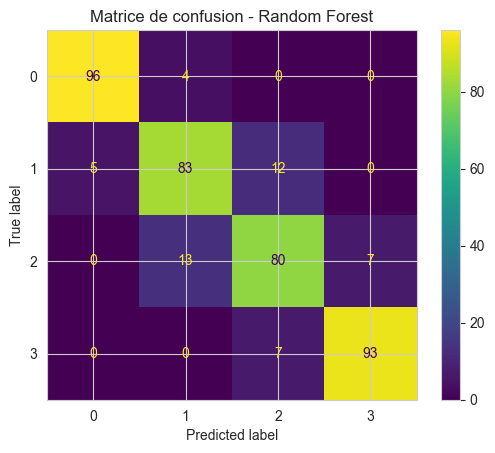

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matrice de confusion - Random Forest")
plt.show()

In [7]:
importances = rf_model.feature_importances_

df_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Top features :")
print(df_importance)

Top features :
          Feature  Importance
13            ram    0.480768
0   battery_power    0.072976
12       px_width    0.056089
11      px_height    0.056000
8       mobile_wt    0.039007
6      int_memory    0.034837
16      talk_time    0.031891
10             pc    0.029158
2     clock_speed    0.028857
15           sc_w    0.027847
14           sc_h    0.027681
4              fc    0.026094
7           m_dep    0.024997
9         n_cores    0.023842
1            blue    0.007304
18   touch_screen    0.007253
3        dual_sim    0.006911
5          four_g    0.006838
19           wifi    0.006499
17        three_g    0.005153


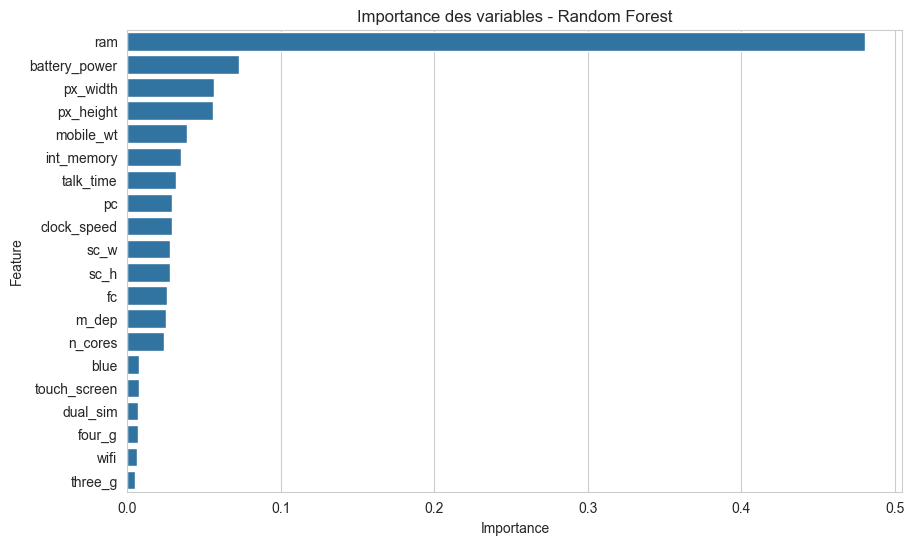

In [8]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=df_importance)
plt.title("Importance des variables - Random Forest")
plt.show()

Arbre de Décision

In [9]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree entraîné")

Decision Tree entraîné


In [10]:
y_pred_dt = dt_model.predict(X_test)

print("Accuracy Decision Tree :", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_dt))

Accuracy Decision Tree : 0.83

Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       100
           1       0.75      0.82      0.78       100
           2       0.74      0.75      0.75       100
           3       0.91      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



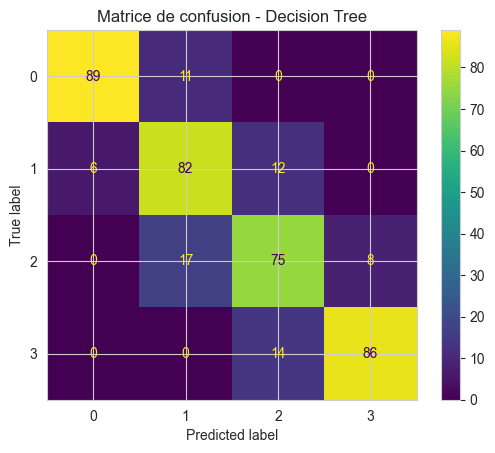

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Matrice de confusion - Decision Tree")
plt.show()

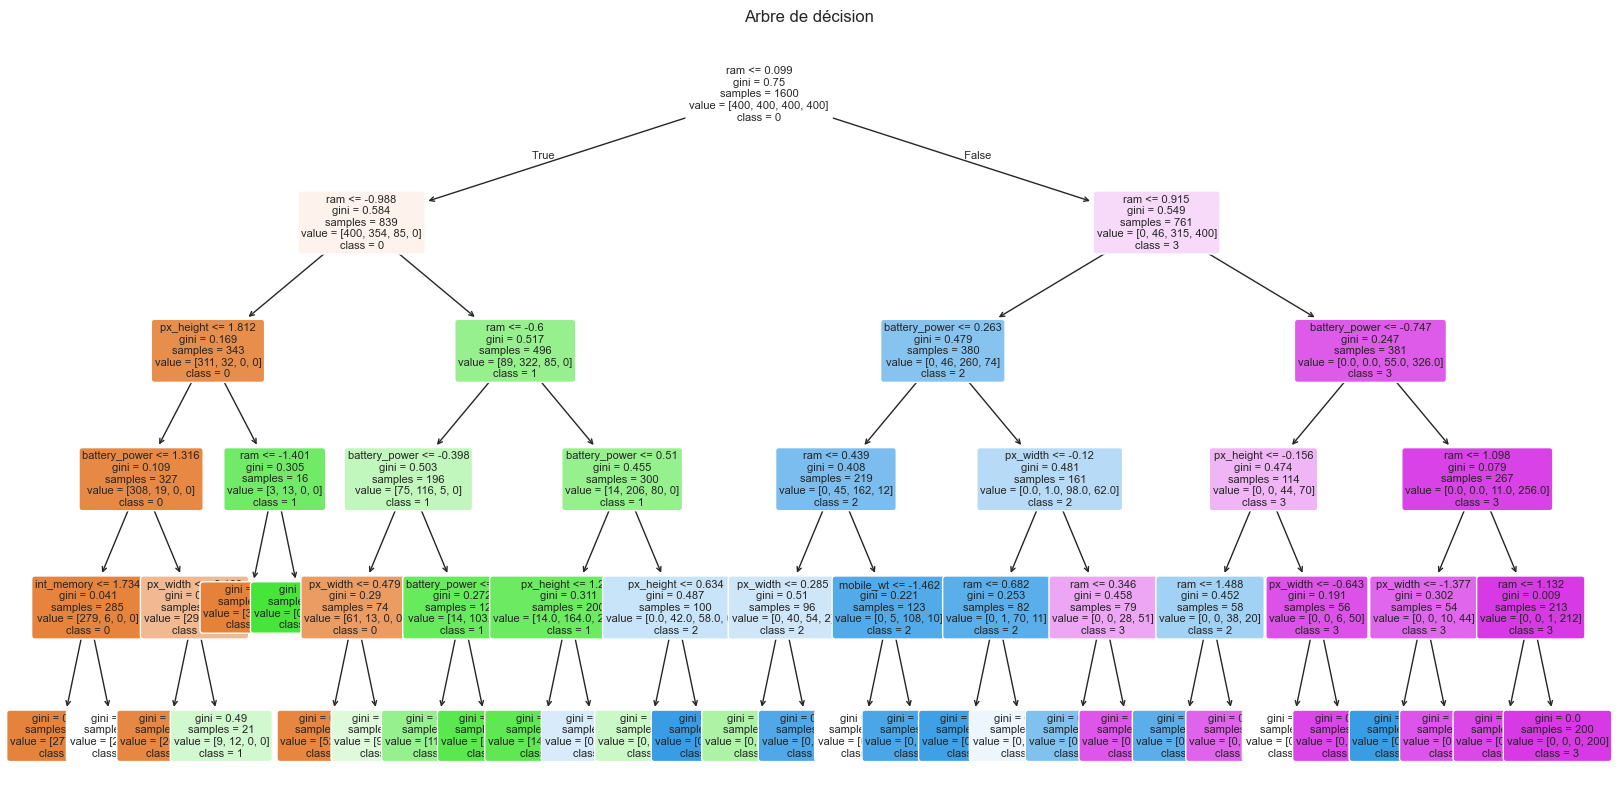

In [12]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(y_train.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Arbre de décision")
plt.show()

Modèle Linéaire

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [14]:
# Chemin vers les données
data_path = "C:/Users/dell/Desktop/DM/datamining1/data/processed/"

X_train = pd.read_csv(f"{data_path}X_train_scaled.csv")
X_test  = pd.read_csv(f"{data_path}X_test_scaled.csv")
y_train = pd.read_csv(f"{data_path}y_train.csv").squeeze()
y_test  = pd.read_csv(f"{data_path}y_test.csv").squeeze()

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (1600, 20)
X_test  : (400, 20)


In [15]:
print("Distribution y_train :")
print(y_train.value_counts())

print("\nDistribution y_test :")
print(y_test.value_counts())

Distribution y_train :
price_range
1    400
0    400
3    400
2    400
Name: count, dtype: int64

Distribution y_test :
price_range
3    100
1    100
0    100
2    100
Name: count, dtype: int64


In [17]:
model = LogisticRegression(max_iter=1000)

In [18]:
model.fit(X_train, y_train)

print("Modèle de régression logistique entraîné")

Modèle de régression logistique entraîné


In [19]:
y_pred = model.predict(X_test)

In [20]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report :")
print(classification_report(y_test, y_pred))

Accuracy : 0.9675

Classification Report :
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.97      0.96      0.96       100
           2       0.95      0.95      0.95       100
           3       0.96      0.98      0.97       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



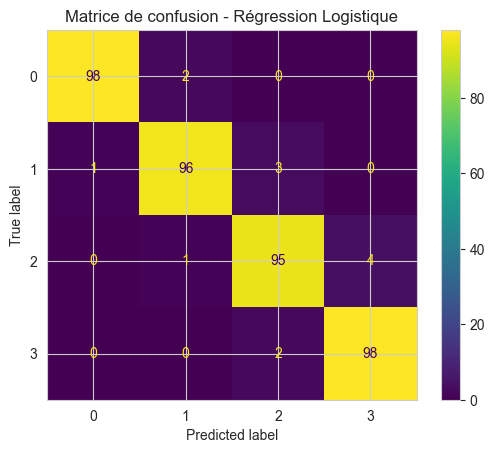

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matrice de confusion - Régression Logistique")
plt.show()

In [22]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

          Feature  Coefficient
19           wifi     0.430905
8       mobile_wt     0.424845
3        dual_sim     0.201155
1            blue     0.178820
18   touch_screen     0.102878
2     clock_speed     0.047431
17        three_g     0.038174
4              fc    -0.001144
10             pc    -0.024199
15           sc_w    -0.027580
9         n_cores    -0.039740
7           m_dep    -0.045773
14           sc_h    -0.060017
16      talk_time    -0.060761
5          four_g    -0.123630
6      int_memory    -0.198889
11      px_height    -1.551698
12       px_width    -1.584200
0   battery_power    -2.708190
13            ram   -10.888761


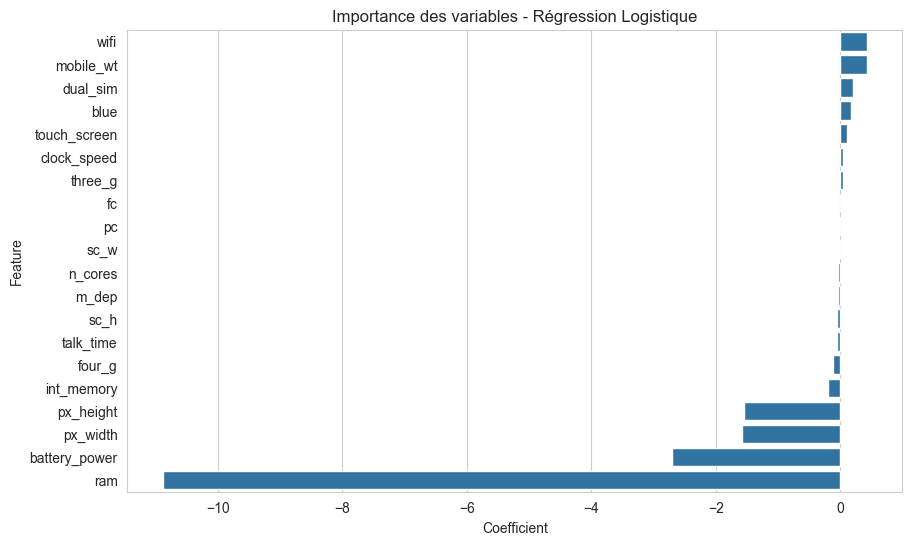

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coefficients)
plt.title("Importance des variables - Régression Logistique")
plt.show()